In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(504, 960, 3)


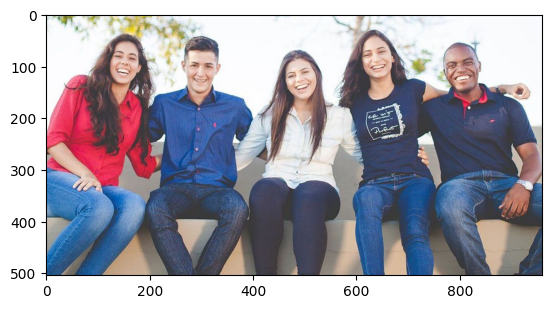

In [23]:
img_path = "people.jpg"
img = cv2.imread(img_path)
print(img.shape)
#plt.imshow(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [24]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [25]:
face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [41]:
face_detections = face_detector.detectMultiScale(img_gray, scaleFactor=1.01, minSize=(500, 500), minNeighbors=8, maxSize=(800, 800))

In [42]:
face_detections

()

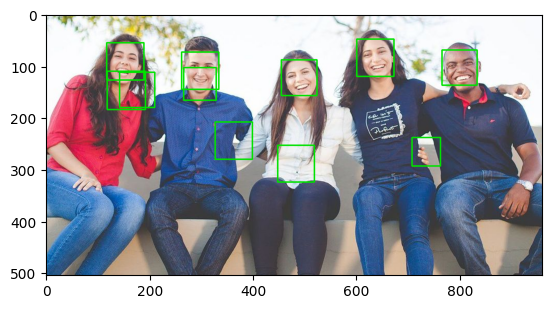

In [43]:
for (x,y,w,h) in face_detections:
    cv2.rectangle(img, (x,y), (x + w, y + h), (0,225,0), 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

Image shape: (504, 960, 3)


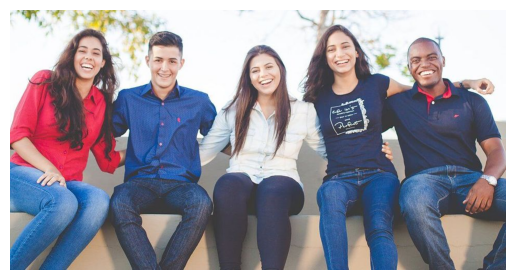

Faces detected: 4


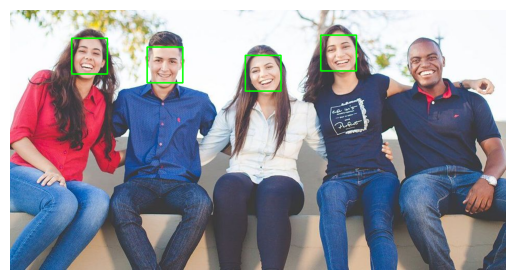

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image from the specified path
img_path = "people.jpg" 
img = cv2.imread(img_path)
print("Image shape:", img.shape)  # Print image dimensions for verification

# Display the original image using matplotlib (convert from BGR to RGB)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide axis ticks
plt.show()

# Convert the image to grayscale as required by the face detector
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load the Haar Cascade classifier for frontal face detection
face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Detect faces in the grayscale image using tuned parameters
face_detections = face_detector.detectMultiScale(
    img_gray,
    scaleFactor=1.7,       # How much the image size is reduced at each image scale
    minNeighbors=8,        # Higher value = fewer detections but higher quality
    minSize=(65, 65)       # Minimum possible face size to detect
)
# Detect faces in the grayscale image using tuned parameters
eye_detections = eye_detector.detectMultiScale(
    img_gray,
    scaleFactor=1.7,       # How much the image size is reduced at each image scale
    minNeighbors=8,        # Higher value = fewer detections but higher quality
    minSize=(65, 65)       # Minimum possible face size to detect
)

# Print the number of faces detected
print(f"Faces detected: {len(face_detections)}")

# Draw rectangles around each detected face on the original image
for (x, y, w, h) in face_detections:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green box with 2px thickness

# Draw rectangles around each detected face on the original image
for (x, y, w, h) in eye_detections:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green box with 2px thickness

# Display the image with detected face boxes
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


Image shape: (504, 960, 3)


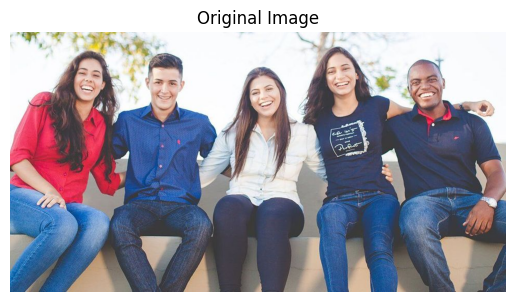

Faces detected: 4
Output image saved to: output_face_eye_detection.jpg


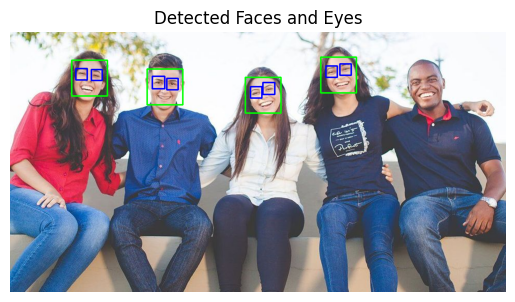

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img_path = "people.jpg" 
img = cv2.imread(img_path)
print("Image shape:", img.shape)

# Display original image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Original Image")
plt.show()

# Convert to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load classifiers
face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Detect faces
face_detections = face_detector.detectMultiScale(
    img_gray,
    scaleFactor=1.7,
    minNeighbors=8,
    minSize=(65, 65)
)

print(f"Faces detected: {len(face_detections)}")

# Draw rectangles around faces and eyes
for (x, y, w, h) in face_detections:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    face_gray = img_gray[y:y+h, x:x+w]
    face_color = img[y:y+h, x:x+w]

    eye_detections = eye_detector.detectMultiScale(
        face_gray,
        scaleFactor=1.03,
        minNeighbors=2,
        minSize=(10, 15)
    )

    for (ex, ey, ew, eh) in eye_detections:
        cv2.rectangle(face_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)

# Save the image with detections
output_path = "output_face_eye_detection.jpg"
cv2.imwrite(output_path, img)
print(f"Output image saved to: {output_path}")

# Display final result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Detected Faces and Eyes")
plt.show()
